In [1]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_subset_CEBPB_KIF11.h5ad"
)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
sys.path.append('../')
from scripts.pairing import assign_state_label
adata.obs["cell_state"] = assign_state_label(
    adata.obs
)
print(adata.obs["cell_state"].value_counts())

cell_state
other         12084
pre_adipo      7379
adipo          3824
lipo_adipo     1038
Name: count, dtype: int64


In [3]:
train_perts = [
    "NC",
    "NC+NC",
    "CEBPB",
    "KIF11",
    "CEBPB+NC",
    "KIF11+NC"
]

adata_train = adata[
    adata.obs["gene"].isin(train_perts)
].copy()

adata_test = adata[
    adata.obs["gene"] == "CEBPB+KIF11"
].copy()

In [4]:
adata_train_subset, hvg_genes,sig_genes = subset_to_hvg(
    adata_train,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt",
    include_signature_genes=True
)

adata_test_subset, hvg_genes,sig_genes = subset_to_hvg(
    adata_test,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt",
    include_signature_genes=True
)

HVG requested: 10000
Signature genes requested: 820
Signature genes used: 481
Total genes used: 10481
HVG requested: 10000
Signature genes requested: 820
Signature genes used: 481
Total genes used: 10481


In [5]:
# load model
scanvi = scvi.model.SCANVI.load(
    "../../resources/scanvi_model_10000",
    adata=adata_train_subset
)

# mapping
scvi.model.SCANVI.prepare_query_anndata(
    adata_train_subset,
    scanvi
)

# latent
adata_train_subset.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_train_subset
    )
)

print("latent shape:")
print(adata_train_subset.obsm["X_scanvi"].shape)

INFO     File ../../resources/scanvi_model_10000/model.pt already downloaded                                       
INFO     Found 100.0% reference vars in query data.                                                                


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


latent shape:
(24283, 50)


In [79]:
adata_train_subset.obsm["X_scanvi"].mean(), adata_train_subset.obsm["X_scanvi"].std(),

(np.float32(0.06431978), np.float32(0.9281083))

In [6]:
# load model
scanvi = scvi.model.SCANVI.load(
    "../../resources/scanvi_model_10000",
    adata=adata_test_subset
)

# mapping
scvi.model.SCANVI.prepare_query_anndata(
    adata_test_subset,
    scanvi
)

# latent
adata_test_subset.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_test_subset
    )
)

print("latent shape:")
print(adata_test_subset.obsm["X_scanvi"].shape)

INFO     File ../../resources/scanvi_model_10000/model.pt already downloaded                                       
INFO     Found 100.0% reference vars in query data.                                                                
latent shape:
(42, 50)


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(
/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 1 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/data/fields/_scanvi.py:56: UserWarning: Category 1 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(


In [ ]:
import math
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scripts.pairing import get_condition_encoder


# =========================================================
# 3. dataset
# =========================================================

class ConditionalFlowDataset(Dataset):
    """
    Online sampler for conditional flow matching.

    Each __getitem__ samples:
        condition c
        z1 ~ p_data(z | c)
        z0 ~ N(0, I)
    """

    def __init__(
        self,
        adata,
        encode_condition_fn,
        latent_key="X_scanvi",
        gene_col="gene",
        dataset_size=200_000,
        random_state=0,
        include_conditions=None
    ):
        self.adata = adata
        self.latent = np.asarray(adata.obsm[latent_key], dtype=np.float32)
        self.genes = adata.obs[gene_col].values
        self.encode_condition_fn = encode_condition_fn
        self.dataset_size = int(dataset_size)

        self.rng = np.random.default_rng(random_state)

        self.pert_to_idx = {}
        unique_perts = np.unique(self.genes)

        for pert in unique_perts:
            idx = np.where(self.genes == pert)[0]
            if len(idx) > 0:
                self.pert_to_idx[pert] = idx

        if include_conditions is not None:
            include_conditions = set(include_conditions)
            self.pert_to_idx = {
                k: v for k, v in self.pert_to_idx.items()
                if k in include_conditions
            }

        self.perts = sorted(list(self.pert_to_idx.keys()))

        if len(self.perts) == 0:
            raise ValueError("No perturbations found for dataset")

        self.latent_dim = self.latent.shape[1]

        # infer condition dimension from first perturbation
        test_cond = self.encode_condition_fn(self.perts[0])
        self.cond_dim = int(test_cond.shape[0])

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        pert = self.rng.choice(self.perts)

        z1_idx = self.rng.choice(self.pert_to_idx[pert])
        z1 = self.latent[z1_idx]

        z0 = self.rng.normal(
            loc=0.0,
            scale=1.0,
            size=self.latent_dim
        ).astype(np.float32)

        cond = self.encode_condition_fn(pert)

        return (
            torch.from_numpy(z0),
            torch.from_numpy(z1),
            torch.from_numpy(cond),
            pert
        )


# =========================================================
# 4. time embedding
# =========================================================

def fourier_time_embedding(
    t,
    dim=64,
    max_period=10000.0
):
    """
    Sinusoidal / Fourier time embedding.

    Parameters
    ----------
    t : torch.Tensor
        shape = (B, 1), values in [0, 1]
    dim : int
        embedding dimension
    max_period : float
        frequency scale

    Returns
    -------
    emb : torch.Tensor
        shape = (B, dim)
    """
    if t.ndim != 2 or t.shape[1] != 1:
        raise ValueError(f"t must have shape (B,1), got {tuple(t.shape)}")

    half_dim = dim // 2
    device = t.device
    dtype = t.dtype

    freqs = torch.exp(
        -math.log(max_period) * torch.arange(
            0, half_dim, device=device, dtype=dtype
        ) / max(half_dim - 1, 1)
    )

    # scale by 2pi so periodicity is more expressive
    args = 2.0 * math.pi * t * freqs.unsqueeze(0)

    emb = torch.cat(
        [torch.sin(args), torch.cos(args)],
        dim=1
    )

    if dim % 2 == 1:
        emb = torch.cat(
            [emb, torch.zeros((t.shape[0], 1), device=device, dtype=dtype)],
            dim=1
        )

    return emb


# =========================================================
# 5. model
# =========================================================

class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.0):
        super().__init__()

        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim)
        )
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(x + self.block(x))


class FlowMLP(nn.Module):
    def __init__(
        self,
        latent_dim,
        cond_dim,
        time_dim=64,
        cond_hidden=1024,
        cond_out=256,
        hidden=1024,
        depth=4,
        dropout=0.0
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.cond_dim = cond_dim
        self.time_dim = time_dim

        # condition encoder
        self.cond_net = nn.Sequential(
            nn.Linear(cond_dim, cond_hidden),
            nn.SiLU(),
            nn.Linear(cond_hidden, cond_out),
            nn.SiLU()
        )

        input_dim = latent_dim + time_dim + cond_out

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.SiLU()
        )

        self.blocks = nn.Sequential(
            *[ResBlock(hidden, dropout=dropout) for _ in range(depth)]
        )

        self.output_layer = nn.Linear(hidden, latent_dim)

    def forward(self, x, t, cond):
        """
        x    : (B, latent_dim)
        t    : (B, 1)
        cond : (B, cond_dim)
        """
        t_emb = fourier_time_embedding(
            t,
            dim=self.time_dim
        )

        cond_latent = self.cond_net(cond)

        h = torch.cat([x, t_emb, cond_latent], dim=1)
        h = self.input_layer(h)
        h = self.blocks(h)

        out = self.output_layer(h)
        return out


# =========================================================
# 6. flow matching loss
# =========================================================

def flow_matching_loss(
    model,
    z0,
    z1,
    cond
):
    """
    Standard conditional flow matching loss with straight-line interpolation.

    z_t = (1 - t) z0 + t z1
    target velocity = z1 - z0
    """
    batch_size = z0.shape[0]
    device = z0.device

    t = torch.rand(batch_size, 1, device=device, dtype=z0.dtype)

    xt = (1.0 - t) * z0 + t * z1
    target = z1 - z0

    pred = model(xt, t, cond)

    loss = ((pred - target) ** 2).mean()
    return loss


# =========================================================
# 7. training
# =========================================================

def train_flow_model(
    adata,
    embedding_dict,
    latent_key="X_scanvi",
    gene_col="gene",
    add_num_guides=True,
    normalize_embedding=False,
    batch_size=256,
    dataset_size=200_000,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    device=None,
    random_state=0,
    model_save_path="best_flow_model.pt",
    num_workers=0
):
    if device is None:
        if torch.backends.mps.is_available():
            device = "mps"
        elif torch.cuda.is_available():
            device = "cuda"
        else:
            device = "cpu"

    encode_fn = get_condition_encoder(
        condition_mode="embedding",
        embedding_dict=embedding_dict,
        add_num_guides=add_num_guides,
        normalize=normalize_embedding
    )

    dataset = ConditionalFlowDataset(
        adata=adata,
        encode_condition_fn=encode_fn,
        latent_key=latent_key,
        gene_col=gene_col,
        dataset_size=dataset_size,
        random_state=random_state
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=num_workers
    )

    model = FlowMLP(
        latent_dim=dataset.latent_dim,
        cond_dim=dataset.cond_dim,
        time_dim=64,
        cond_hidden=1024,
        cond_out=256,
        hidden=1024,
        depth=4,
        dropout=0.0
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = []
    best_loss = float("inf")

    print(f"device: {device}")
    print(f"latent_dim: {dataset.latent_dim}")
    print(f"cond_dim: {dataset.cond_dim}")
    print(f"n_conditions: {len(dataset.perts)}")
    print("conditions:")
    print(dataset.perts)
    
    for epoch in range(max_epochs):
        model.train()
        losses = []

        for z0, z1, cond, pert in loader:
            z0 = z0.to(device, dtype=torch.float32)
            z1 = z1.to(device, dtype=torch.float32)
            cond = cond.to(device, dtype=torch.float32)

            loss = flow_matching_loss(
                model=model,
                z0=z0,
                z1=z1,
                cond=cond
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        epoch_loss = float(np.mean(losses))
        history.append(epoch_loss)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "history": history,
                    "latent_dim": dataset.latent_dim,
                    "cond_dim": dataset.cond_dim,
                    "time_dim": 64,
                    "add_num_guides": add_num_guides,
                    "normalize_embedding": normalize_embedding,
                    "latent_key": latent_key,
                    "gene_col": gene_col,
                    "perts": dataset.perts,
                },
                model_save_path
            )

        if epoch % 10 == 0 or epoch == max_epochs - 1:
            print(f"epoch {epoch:03d} | loss {epoch_loss:.6f}")

    return model, history, dataset


# =========================================================
# 8. ODE sampling / inference
# =========================================================

@torch.no_grad()
def sample_latent_cells(
    model,
    condition,
    encode_condition_fn,
    latent_dim,
    n_cells=100,
    n_steps=100,
    device="cpu",
    z0=None
):
    """
    Generate latent samples for one condition using Euler ODE integration.

    dz/dt = v_theta(z, t, cond)
    """
    model.eval()

    if z0 is None:
        z = torch.randn(n_cells, latent_dim, device=device)
    else:
        z = torch.as_tensor(z0, dtype=torch.float32, device=device)
        if z.shape != (n_cells, latent_dim):
            raise ValueError(
                f"z0 shape must be {(n_cells, latent_dim)}, got {tuple(z.shape)}"
            )

    cond_vec = encode_condition_fn(condition)
    cond = torch.tensor(cond_vec, dtype=torch.float32, device=device).unsqueeze(0)
    cond = cond.repeat(n_cells, 1)

    dt = 1.0 / n_steps

    for step in range(n_steps):
        t_scalar = step / n_steps
        t = torch.full(
            (n_cells, 1),
            fill_value=t_scalar,
            device=device,
            dtype=torch.float32
        )

        v = model(z, t, cond)
        z = z + dt * v

    return z.detach().cpu().numpy()


# =========================================================
# 9. helper for batch generation
# =========================================================

@torch.no_grad()
def generate_for_conditions(
    model,
    conditions,
    encode_condition_fn,
    latent_dim,
    n_cells_per_condition=100,
    n_steps=100,
    device="cpu"
):
    """
    Generate latent samples for multiple perturbations.

    Returns
    -------
    generated_latents : np.ndarray
        shape = (sum cells, latent_dim)
    obs_df : pd.DataFrame
        contains gene column
    """
    all_latents = []
    all_obs = []

    for cond in conditions:
        z = sample_latent_cells(
            model=model,
            condition=cond,
            encode_condition_fn=encode_condition_fn,
            latent_dim=latent_dim,
            n_cells=n_cells_per_condition,
            n_steps=n_steps,
            device=device
        )

        all_latents.append(z)

        obs_df = pd.DataFrame({
            "gene": [cond] * n_cells_per_condition
        })
        all_obs.append(obs_df)

    generated_latents = np.vstack(all_latents).astype(np.float32)
    obs_df = pd.concat(all_obs, axis=0, ignore_index=True)

    return generated_latents, obs_df


# =========================================================
# 10. example usage
# =========================================================

# ---------------------------------------------------------
# Assume:
#   adata_train_subset already exists
#   adata_train_subset.obsm["X_scanvi"] is ready
#   adata_train_subset.obs["gene"] is ready
# ---------------------------------------------------------

# emb = load_gene_embeddings("large")
#
# model, history, dataset = train_flow_model(
#     adata=adata_train_subset,
#     embedding_dict=emb,
#     latent_key="X_scanvi",
#     gene_col="gene",
#     add_num_guides=True,
#     normalize_embedding=False,
#     batch_size=256,
#     dataset_size=200_000,
#     max_epochs=200,
#     lr=1e-3,
#     weight_decay=1e-4,
#     device="mps",   # or "cuda" / "cpu"
#     random_state=0,
#     model_save_path="best_flow_model.pt",
#     num_workers=0
# )


# encode_fn = get_condition_encoder(
#     embedding_dict=emb,
#     add_num_guides=True,
#     normalize=False
# )
#
# conditions_to_generate = [
#     "NC",
#     "NC+NC",
#     "PPARG",
#     "PPARG+NC",
#     "STAT5A+STAT5B"
# ]
#
# generated_latents, generated_obs = generate_for_conditions(
#     model=model,
#     conditions=conditions_to_generate,
#     encode_condition_fn=encode_fn,
#     latent_dim=dataset.latent_dim,
#     n_cells_per_condition=100,
#     n_steps=100,
#     device="mps"
# )
#
# print(generated_latents.shape)
# print(generated_obs.head())


In [ ]:
import sys
sys.path.append('../')
from scripts.pairing import build_pairs_from_anndata, load_gene_embeddings


emb = load_gene_embeddings("large")
model, history, dataset = train_flow_model(
    adata=adata_train_subset,
    embedding_dict=emb,
    latent_key="X_scanvi",
    gene_col="gene",
    add_num_guides=True,
    normalize_embedding=False,
    batch_size=256,
    dataset_size=200_000,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    device="mps",   # or "cuda" / "cpu"
    random_state=0,
    model_save_path="try_best_flow_model.pt",
    num_workers=0
)

device: mps
latent_dim: 50
cond_dim: 3073
n_conditions: 6
epoch 000 | loss 1.077848
epoch 010 | loss 1.616044
epoch 020 | loss 0.946161
epoch 030 | loss 0.839768
epoch 040 | loss 0.811698
epoch 050 | loss 1.389795
epoch 060 | loss 0.919903
epoch 070 | loss 0.841665
epoch 080 | loss 0.810596
epoch 090 | loss 0.795179
epoch 100 | loss 0.783864
epoch 110 | loss 0.779662
epoch 120 | loss 0.776712
epoch 130 | loss 0.773411
epoch 140 | loss 0.769095


In [ ]:
encode_fn = get_condition_encoder(
    embedding_dict=emb,
    add_num_guides=True,
    normalize=False
)

conditions_to_generate = [
    "NC",
    "NC+NC",
    "PPARG",
    "PPARG+NC",
    "STAT5A+STAT5B"
]

generated_latents, generated_obs = generate_for_conditions(
    model=model,
    conditions=conditions_to_generate,
    encode_condition_fn=encode_fn,
    latent_dim=dataset.latent_dim,
    n_cells_per_condition=100,
    n_steps=100,
    device="mps"
)

print(generated_latents.shape)
print(generated_obs.head())

In [ ]:
import sys
sys.path.append('../')
from scripts.pairing import build_pairs_from_anndata, load_gene_embeddings


emb = load_gene_embeddings("large")

pairs = build_pairs_from_anndata(

    adata_train_subset,

    latent_key="X_scanvi",
    state_col="cell_state",

    condition_mode="embedding",

    embedding_dict=emb,
    normalize_embedding= True,
    add_num_guides=True,
    small_threshold=0,
    n_repeat_ot_pairs = 1
)

print(len(pairs))

CEBPB 8628 ot_pairs
CEBPB+NC 28 ot_pairs
CEBPB+NC 77 random (NC fallback)
KIF11 4671 ot_pairs
KIF11+NC 26 ot_pairs
KIF11+NC 23 random (NC fallback)
13453


In [10]:
import numpy as np

lengths = np.array([
    np.linalg.norm(p["z1"] - p["z0"])
    for p in pairs
])

print("mean:", lengths.mean())
print("std:", lengths.std())
print("min:", lengths.min())
print("max:", lengths.max())

print("percentiles:")
for q in [50, 75, 90, 95, 99]:
    print(q, np.percentile(lengths, q))

mean: 5.448623
std: 0.83147174
min: 3.153792
max: 7.999227
percentiles:
50 5.325015
75 5.8919263
90 6.596346
95 7.128182
99 7.839333


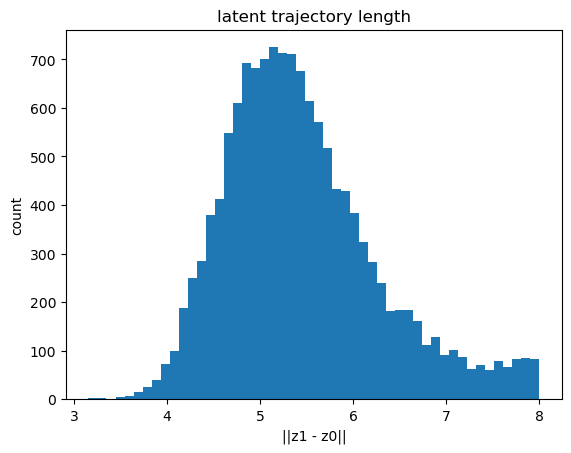

In [11]:
import matplotlib.pyplot as plt

plt.hist(lengths, bins=50)

plt.title("latent trajectory length")

plt.xlabel("||z1 - z0||")

plt.ylabel("count")

plt.show()

In [12]:
from scripts.flow_dataset import FlowPairDataset
import torch
dataset = FlowPairDataset(pairs)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=256,
    shuffle=True
)

In [13]:
import torch
import torch.nn as nn


class FlowMLP(nn.Module):

    def __init__(
        self,

        dim=512,

        cond_dim=1536,

        cond_hidden=512,

        cond_out=64,

        hidden=1024
    ):
        super().__init__()

        # -------------------
        # condition encoder
        # -------------------

        self.cond_net = nn.Sequential(

            nn.Linear(cond_dim, cond_hidden),

            nn.SiLU(),

            nn.Linear(cond_hidden, cond_out),

            nn.SiLU()

        )


        # -------------------
        # main flow network
        # -------------------

        self.net = nn.Sequential(

            nn.Linear(dim + cond_out + 1, hidden),

            nn.SiLU(),

            nn.Linear(hidden, hidden),

            nn.SiLU(),

            nn.Linear(hidden, hidden),

            nn.SiLU(),

            nn.Linear(hidden, dim)

        )


    def forward(

        self,

        x,

        t,

        cond

    ):

        """
        x: (B, latent_dim)

        t: (B, 1)

        cond: (B, cond_dim)
        """

        cond_latent = self.cond_net(cond)

        h = torch.cat(

            [

                x,

                cond_latent,

                t

            ],

            dim=1

        )

        return self.net(h)

In [14]:
# from scripts.flow_model import FlowMLP
latent_dim = pairs[0]["z0"].shape[0]

cond_dim = pairs[0]["cond"].shape[0]

model = FlowMLP(

    dim = latent_dim,

    cond_dim = cond_dim
)

In [20]:
import math


def cosine_down_up_schedule(
    epoch,
    lr,
    min_lr,
    anneal_epochs,
    warmup_epochs
):

    # ------------------
    # phase 1: cosine decay
    # ------------------

    if epoch <= anneal_epochs:

        ratio = epoch / anneal_epochs

        return min_lr + 0.5 * (lr - min_lr) * (

            1 + math.cos(math.pi * ratio)

        )


    # ------------------
    # phase 2: cosine warmup
    # ------------------

    epoch2 = epoch - anneal_epochs


    if epoch2 <= warmup_epochs:

        ratio = epoch2 / warmup_epochs

        return min_lr + 0.5 * (lr - min_lr) * (

            1 - math.cos(math.pi * ratio)

        )


    return lr

In [ ]:
from tqdm.auto import tqdm
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



def train_flow_model(

    model,

    loader,

    loss_fn,

    optimizer=None,

    device="cpu",

    max_epochs=500,

    patience=15,

    min_delta=1e-4,

    save_dir="model",

    show_batch_progress=True,

    # lr schedule
    lr=1e-3,

    min_lr=1e-5,

    anneal_epochs=100,

    warmup_epochs=50

):

    device = torch.device(device)

    model = model.to(device)


    if optimizer is None:

        optimizer = torch.optim.Adam(

            model.parameters(),

            lr=lr

        )


    save_dir = Path(save_dir)

    save_dir.mkdir(

        parents=True,

        exist_ok=True

    )


    save_path = save_dir / "best_model.pt"

    loss_csv_path = save_dir / "loss_curve.csv"

    plot_path = save_dir / "loss_curve.png"


    best_loss = float("inf")

    epochs_no_improve = 0

    all_epoch_losses = []

    all_lrs = []


    epoch_bar = tqdm(

        range(max_epochs),

        desc="Training",

        leave=True

    )


    for epoch in epoch_bar:


        # ------------------
        # update lr
        # ------------------

        current_lr = cosine_down_up_schedule(

            epoch,

            lr,

            min_lr,

            anneal_epochs,

            warmup_epochs

        )


        for g in optimizer.param_groups:

            g["lr"] = current_lr


        all_lrs.append(current_lr)


        model.train()

        losses = []


        if show_batch_progress:

            batch_bar = tqdm(

                loader,

                leave=False,

                desc=f"epoch {epoch}"

            )

        else:

            batch_bar = loader


        for z0, z1, cond in batch_bar:


            z0 = z0.to(device)

            z1 = z1.to(device)

            cond = cond.to(device)


            loss = loss_fn(

                model,

                z0,

                z1,

                cond

            )


            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


            loss_val = loss.item()

            losses.append(loss_val)


            if show_batch_progress:

                batch_bar.set_postfix(

                    loss=f"{loss_val:.4f}"

                )


        epoch_loss = float(np.mean(losses))

        all_epoch_losses.append(epoch_loss)


        epoch_bar.set_postfix(

            loss=f"{epoch_loss:.5f}",

            best=f"{best_loss:.5f}",

            lr=f"{current_lr:.2e}"

        )


        # save best
        if epoch_loss < best_loss - min_delta:

            best_loss = epoch_loss

            epochs_no_improve = 0


            torch.save(

                {

                    "model_state_dict": model.state_dict(),

                    "optimizer_state_dict": optimizer.state_dict(),

                    "epoch": epoch,

                    "loss": best_loss

                },

                save_path

            )


            epoch_bar.write(

                f"[SAVE] epoch {epoch} loss {best_loss:.6f}"

            )


        else:

            epochs_no_improve += 1


        if epochs_no_improve >= patience:

            epoch_bar.write(

                f"\nEARLY STOP at epoch {epoch}"

            )

            break


    # ------------------
    # save logs
    # ------------------

    df = pd.DataFrame(

        {

            "epoch": np.arange(len(all_epoch_losses)),

            "loss": all_epoch_losses,

            "lr": all_lrs

        }

    )


    df.to_csv(

        loss_csv_path,

        index=False

    )


    # ------------------
    # plot
    # ------------------

    plt.figure()

    plt.plot(all_epoch_losses)

    plt.xlabel("epoch")

    plt.ylabel("loss")

    plt.title("Loss")

    plt.savefig(plot_path)

    plt.close()


    print("\nBest loss:", best_loss)

    print("saved to:", save_dir)


    return model

In [ ]:
history = train_flow_model(

    model,

    loader,

    loss_fn=flow_matching_loss_pairs,

    device="mps",

    lr=1e-3,

    min_lr=1e-5,

    anneal_epochs=150,

    warmup_epochs=80,

    save_dir="model/flow_scanvi_large_emb"
)

In [15]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scripts.flow_loss import (
    flow_matching_loss_pairs,
    flow_matching_loss_gaussian
)


device = "mps"

model.to(device)

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=1e-3
)


# ------------------
# config
# ------------------

max_epochs = 500

patience = 15          # early stop patience

min_delta = 1e-4       # minimum improvement

save_path = Path("model/best_flow_no_whiten.pt")

loss_csv_path = Path("model/loss_curve.csv")

plot_path = Path("model/loss_curve.png")

save_path.parent.mkdir(parents=True, exist_ok=True)


# ------------------
# tracking
# ------------------

best_loss = float("inf")

epochs_no_improve = 0

all_epoch_losses = []


# ------------------
# training loop
# ------------------

for epoch in range(max_epochs):

    losses = []

    model.train()

    for z0, z1, cond in loader:

        z0 = z0.to(device)

        z1 = z1.to(device)

        cond = cond.to(device)


        loss = flow_matching_loss_pairs(

            model,

            z0,

            z1,

            cond

        )


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        losses.append(

            loss.item()

        )


    epoch_loss = float(np.mean(losses))

    all_epoch_losses.append(epoch_loss)


    # ------------------
    # save best model
    # ------------------

    if epoch_loss < best_loss - min_delta:

        best_loss = epoch_loss

        epochs_no_improve = 0


        torch.save(

            {

                "model_state_dict": model.state_dict(),

                "optimizer_state_dict": optimizer.state_dict(),

                "epoch": epoch,

                "loss": best_loss

            },

            save_path

        )


        print(

            f"[SAVE] epoch {epoch}  loss {best_loss:.6f}"

        )


    else:

        epochs_no_improve += 1


    # ------------------
    # print progress
    # ------------------

    if epoch % 20 == 0:

        print(

            f"epoch {epoch}  loss {epoch_loss:.6f}"

        )


    # ------------------
    # early stopping
    # ------------------

    if epochs_no_improve >= patience:

        print(

            f"\nEARLY STOP at epoch {epoch}"

        )

        break


# ------------------
# save loss curve
# ------------------

loss_df = pd.DataFrame(

    {

        "epoch": np.arange(len(all_epoch_losses)),

        "loss": all_epoch_losses

    }

)

loss_df.to_csv(

    loss_csv_path,

    index=False

)


# ------------------
# plot
# ------------------

plt.figure()

plt.plot(all_epoch_losses)

plt.xlabel("epoch")

plt.ylabel("loss")

plt.title("Flow Matching Training Loss")

plt.savefig(plot_path)

plt.close()


print("\nBest loss:", best_loss)

print("model saved to:", save_path)

print("loss curve saved to:", loss_csv_path)

print("plot saved to:", plot_path)

[SAVE] epoch 0  loss 0.585791
epoch 0  loss 0.585791
[SAVE] epoch 1  loss 0.574979
[SAVE] epoch 2  loss 0.571734
[SAVE] epoch 3  loss 0.568367
[SAVE] epoch 4  loss 0.565365
[SAVE] epoch 5  loss 0.561151
[SAVE] epoch 6  loss 0.556592
[SAVE] epoch 7  loss 0.547595
[SAVE] epoch 8  loss 0.536354
[SAVE] epoch 9  loss 0.524755
[SAVE] epoch 10  loss 0.517557
[SAVE] epoch 11  loss 0.510346
[SAVE] epoch 12  loss 0.503299
[SAVE] epoch 13  loss 0.499089
[SAVE] epoch 14  loss 0.493142
[SAVE] epoch 15  loss 0.487908
[SAVE] epoch 16  loss 0.484252
[SAVE] epoch 17  loss 0.477447
[SAVE] epoch 18  loss 0.471911
[SAVE] epoch 19  loss 0.464925
[SAVE] epoch 20  loss 0.457062
epoch 20  loss 0.457062
[SAVE] epoch 21  loss 0.448143
[SAVE] epoch 22  loss 0.440841
[SAVE] epoch 23  loss 0.428802
[SAVE] epoch 24  loss 0.417320
[SAVE] epoch 25  loss 0.403827
[SAVE] epoch 26  loss 0.390540
[SAVE] epoch 27  loss 0.373849
[SAVE] epoch 28  loss 0.358490
[SAVE] epoch 29  loss 0.342218
[SAVE] epoch 30  loss 0.326269
[S

In [60]:
import numpy as np
from sklearn.mixture import GaussianMixture


def sample_latent_gmm(
    latent_ctrl,
    n_cells=100,
    n_components=4,
    fit_seed=0,
    sample_seed=42
):

    # Fit model
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=fit_seed
    )
    gmm.fit(latent_ctrl)

    # Temporarily control RNG
    rng = np.random.RandomState(sample_seed)
    old_state = np.random.get_state()
    np.random.set_state(rng.get_state())

    try:
        samples, _ = gmm.sample(n_cells)
    finally:
        np.random.set_state(old_state)

    return samples


In [71]:
import numpy as np

mask_ctrl = adata_train_subset.obs["gene"].isin(["NC","NC+NC"])

latent_ctrl = adata_train_subset.obsm["X_scanvi"][mask_ctrl]

print(latent_ctrl.shape)
z_NCNC = sample_latent_gmm(

    latent_ctrl,
    n_cells=100
)

(8688, 50)


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/sklearn/mixture/_base.py:468: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


In [63]:
import numpy as np

mask_ctrl = adata_train_subset.obs["gene"].isin(["NC"])

latent_ctrl = adata_train_subset.obsm["X_scanvi"][mask_ctrl]

print(latent_ctrl.shape)
z_NC = sample_latent_gmm(

    latent_ctrl,
    n_cells=100
)

(8660, 50)


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/sklearn/mixture/_base.py:468: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


In [16]:
import scanpy as sc
import torch
import joblib
import numpy as np
import pandas as pd

control_path = "../../data/preprocessed/control_cells/NC_NC_control_cells.h5ad"

adata_ctrl_NCNC = sc.read_h5ad(control_path)



adata_ctrl_hvg, hvg_genes,sig_genes = subset_to_hvg(
    adata_ctrl_NCNC,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt",
    include_signature_genes=True
)


adata_ctrl_hvg.obs["cell_state"] = pd.Categorical(

    ["unknown"] * adata_ctrl_hvg.n_obs,

    categories=scanvi.adata_manager.get_state_registry(
        "labels"
    )["categorical_mapping"]

)

# latent
z_NCNC = (
    scanvi.get_latent_representation(
        adata_ctrl_hvg
    )
)

print("latent shape:")
print(z_NCNC.shape)

HVG requested: 10000
Signature genes requested: 820
Signature genes used: 481
Total genes used: 10481
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
latent shape:
(100, 50)


In [17]:
import scanpy as sc
import torch
import joblib
import numpy as np
import pandas as pd

control_path = "../../data/preprocessed/control_cells/NC_control_cells.h5ad"

adata_ctrl_NC = sc.read_h5ad(control_path)



adata_ctrl_hvg, hvg_genes,sig_genes = subset_to_hvg(
    adata_ctrl_NC,
    hvg_path="../../data/preprocessed/HVG/hvg10000_genes.txt",
    include_signature_genes=True
)


adata_ctrl_hvg.obs["cell_state"] = pd.Categorical(

    ["unknown"] * adata_ctrl_hvg.n_obs,

    categories=scanvi.adata_manager.get_state_registry(
        "labels"
    )["categorical_mapping"]

)

z_NC = (
    scanvi.get_latent_representation(
        adata_ctrl_hvg
    )
)

print("latent shape:")
print(z_NC.shape)

HVG requested: 10000
Signature genes requested: 820
Signature genes used: 481
Total genes used: 10481
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
latent shape:
(100, 50)


In [72]:
import importlib

import scripts.flow_pred

importlib.reload(scripts.flow_pred)

from scripts.flow_pred import sample_all_perts


emb = load_gene_embeddings("large")

latent_all, pert_labels = sample_all_perts(

    model,
    
    embedding_dict=emb,
    condition_mode="embedding",

    pert_list = ["CEBPB+KIF11"],

    z_NC=z_NC,

    z_NCNC=z_NCNC,

    n_steps=100,
    normalize_embedding= True,
    add_num_guides=True
)

# gene_pred = pca.inverse_transform(

#     latent_all

# )
# gene_pred = np.clip(gene_pred,0,None)

CEBPB+KIF11          control: NC+NC latent: (100, 50)


In [55]:
import torch
import numpy as np


def decode_scanvi_latent(
    scanvi_model,
    latent,
    library_size=1e5,
    batch_size=512,
    device="cpu",
    mode="scale",
):

    device = torch.device(device)

    latent_t = torch.tensor(
        latent,
        dtype=torch.float32,
        device=device
    )

    decoder = scanvi_model.module.decoder
    dispersion = scanvi_model.module.dispersion

    outputs = []

    for i in range(0, latent_t.shape[0], batch_size):

        z = latent_t[i:i+batch_size]

        ##################################
        # library size
        ##################################

        library = torch.log(
            torch.ones(
                (z.shape[0], 1),
                device=device
            ) * library_size
        )

        ##################################
        # categorical covariates
        ##################################

        batch_index = torch.zeros(
            (z.shape[0], 1),
            dtype=torch.long,
            device=device
        )

        y = torch.zeros(
            (z.shape[0], 1),
            dtype=torch.long,
            device=device
        )

        ##################################
        # decode
        ##################################

        with torch.no_grad():

            px_scale, px_r, px_rate, px_dropout = decoder(

                dispersion,
                z,
                library,
                batch_index,
                y
            )

        ##################################
        # choose expression type
        ##################################

        if mode == "scale":

            expr = px_scale * library_size

        elif mode == "rate":

            expr = px_rate

        else:

            raise ValueError("mode must be scale or rate")

        outputs.append(

            expr.cpu().numpy()

        )

    return np.concatenate(outputs, axis=0)

In [71]:
gene_pred_decode = decode_scanvi_latent(
    scanvi,
    latent_all,
    library_size=1e4,
    device="cpu",
)

gene_pred_decode

array([[0.00235165, 0.00711968, 0.00204589, ..., 0.00962931, 0.14395863,
        0.00241531],
       [0.00315189, 0.01096258, 0.00405015, ..., 0.0121426 , 0.32053894,
        0.00252753],
       [0.00106322, 0.00319995, 0.00218254, ..., 0.00546502, 0.07318579,
        0.00075506],
       ...,
       [0.01362987, 0.00378743, 0.00738308, ..., 0.01142453, 0.08733567,
        0.00172355],
       [0.00181446, 0.00408242, 0.0031566 , ..., 0.01301094, 0.08881862,
        0.00093966],
       [0.00132924, 0.00475822, 0.00210954, ..., 0.01729084, 0.35892066,
        0.00086375]], shape=(100, 10481), dtype=float32)

In [73]:
import numpy as np
from sklearn.neighbors import NearestNeighbors


def latent_to_expression_nn(

    latent_query,

    latent_train,

    adata_train,

    k=30,

    method="softmax",

    eps=1e-8
):

    nbrs = NearestNeighbors(

        n_neighbors=k,

        metric="euclidean"

    ).fit(latent_train)


    distances, indices = nbrs.kneighbors(latent_query)


    # convert sparse to dense if needed
    gene_train = adata_train.X

    if not isinstance(gene_train, np.ndarray):

        gene_train = gene_train.toarray()


    preds = []


    for d, idx in zip(distances, indices):

        neigh_expr = gene_train[idx]


        # 保證 2D
        neigh_expr = np.atleast_2d(neigh_expr)

        d = np.atleast_1d(d)


        if method == "mean":

            pred = neigh_expr.mean(axis=0)


        elif method == "distance":

            w = 1 / (d + eps)

            w = w / w.sum()

            pred = (neigh_expr * w[:, None]).sum(axis=0)


        elif method == "softmax":

            w = np.exp(-d)

            w = w / w.sum()

            pred = (neigh_expr * w[:, None]).sum(axis=0)


        else:

            raise ValueError(

                "method must be:\n"

                "mean\n"

                "distance\n"

                "softmax"

            )


        preds.append(pred)


    return np.vstack(preds)

In [74]:
gene_pred_nn = latent_to_expression_nn(

    latent_query = latent_all,

    latent_train = adata_train_subset.obsm["X_scanvi"],

    adata_train = adata_train,

    k = 3,

    method = "softmax" #distance,mean,softmax
)

In [73]:
import importlib

import scripts.save_predict

importlib.reload(scripts.save_predict)

from scripts.save_predict import save_prediction_h5ad
prediction_h5ad_file_path = "prediction.h5ad"
adata_pred = save_prediction_h5ad(

    X_pred_full = gene_pred_nn,

    adata_full = adata_train,
    latent_all= latent_all,

    predict_perturbations = ['CEBPB+KIF11'],

    genes_to_predict_path = "../../data/predict_genes_2.txt",

    prediction_h5ad_file_path = prediction_h5ad_file_path,

)

genes_to_predict: 36601
latent stored: (100, 50)

Saved prediction: prediction.h5ad
gene order verified


/opt/anaconda3/envs/X-Cells/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [74]:
import numpy as np


def merge_decoder_into_full_matrix(

    X_full,
    X_hvg,
    adata_full,
    scanvi_model
):
    """
    把 decoder 預測的 HVG expression 填回 full gene matrix

    Parameters
    ----------
    X_full
        (n_cells, n_all_genes)

    X_hvg
        (n_cells, n_hvg_genes)

    adata_full
        用來提供 gene name 順序

    scanvi_model
        用來取得 HVG gene list
    """

    ##################################
    # gene name list
    ##################################

    full_gene_names = adata_full.var_names.to_numpy()

    hvg_gene_names = scanvi_model.adata.var_names.to_numpy()

    ##################################
    # 找到 HVG 在 full matrix 中的位置
    ##################################

    gene_to_index = {

        g:i for i,g in enumerate(full_gene_names)

    }

    hvg_indices = [

        gene_to_index[g]

        for g in hvg_gene_names

        if g in gene_to_index

    ]

    ##################################
    # copy matrix
    ##################################

    X_merged = X_full.copy()

    ##################################
    # 覆蓋 HVG columns
    ##################################

    X_merged[:, hvg_indices] = X_hvg


    return X_merged

In [75]:
X_combined = merge_decoder_into_full_matrix(

    X_full = gene_pred_nn,

    X_hvg = gene_pred_decode,

    adata_full = adata_train,

    scanvi_model = scanvi
)

In [76]:
X_combined

array([[0.00235165, 0.        , 0.        , ..., 0.00390864, 0.04977858,
        0.        ],
       [0.00315189, 0.        , 0.        , ..., 0.00472302, 0.04907958,
        0.        ],
       [0.00106322, 0.        , 0.        , ..., 0.00123224, 0.03174815,
        0.        ],
       ...,
       [0.01362987, 0.        , 0.        , ..., 0.00597681, 0.20321737,
        0.        ],
       [0.00181446, 0.        , 0.        , ..., 0.00119484, 0.02088876,
        0.        ],
       [0.00132924, 0.        , 0.        , ..., 0.00231192, 0.03303145,
        0.        ]], shape=(100, 36601))

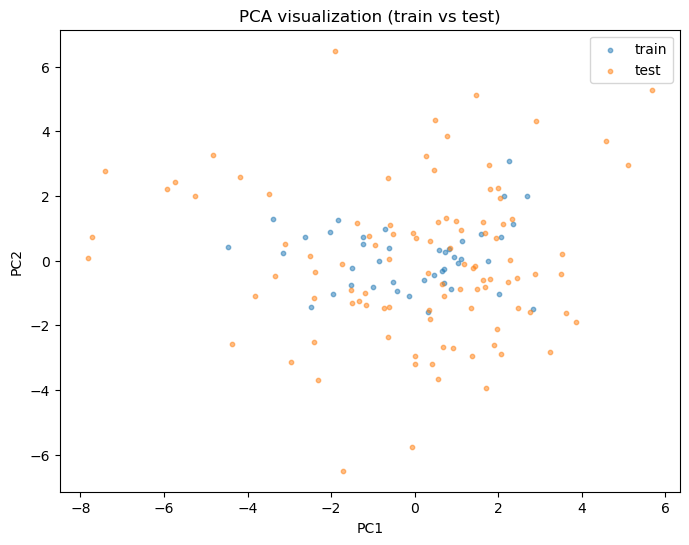

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# 取出 PCA features
X_train_pca512 = adata_test_subset.obsm["X_scanvi"]
X_test_pca512  = latent_all

# 合併
X_all = np.vstack([X_train_pca512, X_test_pca512])

# 建立來源標籤
labels_source = (
    ["train"] * X_train_pca512.shape[0] +
    ["test"]  * X_test_pca512.shape[0]
)

labels_source = np.array(labels_source)

# 再做 PCA -> 2D 用於視覺化
pca_2d = PCA(n_components=2, random_state=42)

X_2d = pca_2d.fit_transform(X_all)

# 轉 dataframe
df_plot = pd.DataFrame({
    "PC1": X_2d[:,0],
    "PC2": X_2d[:,1],
    "dataset": labels_source
})

# 畫圖
plt.figure(figsize=(8,6))

for label in df_plot["dataset"].unique():

    subset = df_plot[df_plot["dataset"] == label]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.5,
        s=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA visualization (train vs test)")

plt.legend()

plt.show()

In [68]:
import pandas as pd

centroid_df = pd.read_csv(
    "../../data/preprocessed/centroid/centroid-CEBPB_KIF11.csv",
    index_col=0
)
single_centroid = centroid_df.loc["single_centroid"].values
double_centroid = centroid_df.loc["double_centroid"].values

target_pert = "CEBPB+KIF11"

n_guides = len(target_pert.split("+"))

if n_guides == 1:

    perturbed_centroid = single_centroid

elif n_guides == 2:

    perturbed_centroid = double_centroid

In [69]:
adata = sc.read_h5ad(
    "../../data/obesity_subset_CEBPB_KIF11.h5ad"
)

mask_gt = (

    adata.obs["gene"]

    == target_pert

)

X_gt_full = adata[mask_gt].X

if not isinstance(X_gt_full, np.ndarray):

    X_gt_full = X_gt_full.toarray()


X_gt_full = X_gt_full

print("GT shape:", X_gt_full.shape)

GT shape: (42, 36601)


In [76]:
from scripts.scoring import  pearson_score,mmd_metric

pearson_score = pearson_score(

    X_gt_full,
    gene_pred_nn,
    perturbed_centroid

)

mmd_score = mmd_metric(

    X_gt_full,
    gene_pred_nn

)


print("\nRESULT")

print("pearson_delta:", pearson_score)

print("mmd:", mmd_score)


RESULT
pearson_delta: 0.46394479084928464
mmd: 0.340792707109387


In [ ]:
RESULT
pearson_delta: 0.46667159651343015
mmd: 0.29941705372841637


np.float64(0.7670668468310093)

In [25]:
print(X_gt_full.shape)
print(gene_pred_nn.shape)

print(X_gt_full.mean(), gene_pred_nn.mean())
print(X_gt_full.std(), gene_pred_nn.std())

(42, 36601)
(100, 36601)
0.4240006515055306 0.4113414412134221
1.242188995503134 1.1067203159825296
